# Разработка алгоритма жадного добавления

Для сравнительной оценки получаемых результатов с подходом описанным в СП 11.13130.2009

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка исходных данных

Здесь используем данные для Сосновоборска, как тестовые.

5514 12199
Узлов исходного ГДС: 5514
Зданий: 1595
Зданий: 1502


<Axes: >

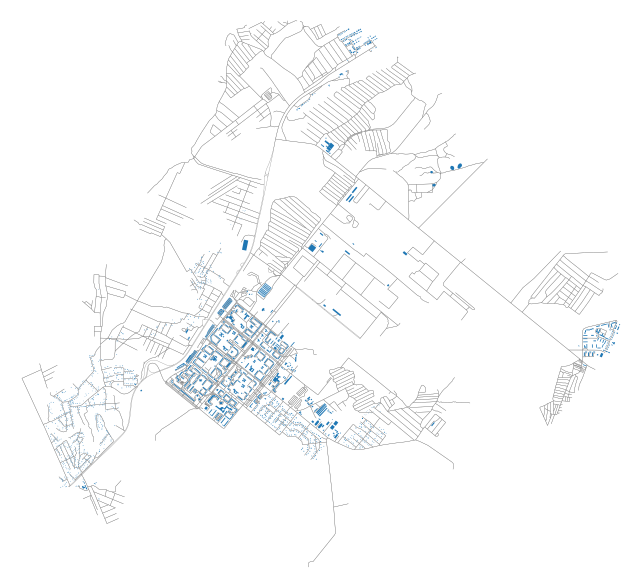

In [2]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# Загружаем данные
G = ox.load_graphml(r'tests\data\test_rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# # Создаем реверсный граф
# GR = nx.reverse(G, copy=True)

# Загрузка зданий
buildings = gpd.read_file(r'tests\data\buildings.gpkg')

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)


# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)
print('Узлов исходного ГДС:', len(nodes_gdf))

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

fig, ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
buildings.plot(ax=ax)

# 1. Разработка алгоритма

## 1.1. Обратный Дейкстра

! Не имеет смысла. т.к. достаточно один раз развернуть граф.

In [3]:
# from heapq import heappop, heappush
# from itertools import count
# from typing import Any
# from networkx import Graph


# # def multi_source_dijkstra_reversed(
# #         G: Graph,
# #         sources: Any,
# #         target: Any | None = None,
# #         cutoff: Any | None = None,
# #         weight: str = "weight"
# # ):
# #     return nx.multi_source_dijkstra(
# #         G,
# #         sources = sources,
# #         target  = target,
# #         cutoff  = cutoff,
# #         weight  = weight, 
# #         )


## 1.2. Расчет матрицы достижимости от всех зданий

In [4]:
buildings.head(5)

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,geometry,node,node_distance
0,114435873,None,None,apartments,улица Ленинского Комсомола,2,9,None,"POLYGON ((93.34238 56.12589, 93.3425 56.12597,...",9085465307,6.523538
1,114435874,None,None,store,улица Ленинского Комсомола,None,None,None,"POLYGON ((93.33886 56.12348, 93.33875 56.1234,...",9085465281,15.532267
2,114435883,None,None,apartments,улица Ленинского Комсомола,14,9,None,"POLYGON ((93.33509 56.12247, 93.33522 56.12256...",1548378909,15.114030
3,114435884,Айсберг,None,retail,улица Ленинского Комсомола,16,2,None,"POLYGON ((93.33517 56.12089, 93.33507 56.12093...",1548378914,29.840848
4,114435890,None,None,store,улица Ленинского Комсомола,10,2,None,"POLYGON ((93.33343 56.12335, 93.33358 56.12328...",1526082578,25.869531


In [5]:
from genesis.swiss_knife import MSF
from genesis.utils import Progressbar, TimeCheckPoint

time_bound = 9


df_size = len(buildings)
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
for id, building in buildings.iterrows():
    node = building['node']
    # length, path = multi_source_dijkstra_reversed(G, sources = [node], cutoff = time_bound, weight = 'travel_time')
    # length, path = MSF(GR, sources = [node], cutoff = time_bound, weight = 'travel_time')
    length = nx.shortest_path_length(G, target = node, weight = 'travel_time')
    length = {k:v for k,v in length.items() if v <= time_bound}   
    # length = {k:v for k,v in length.items() if v in }
    d[id] = pd.Series(length).notna()
    pb()

matrix = pd.DataFrame(d).T
matrix.shape

print('Потребовалось времени:', t())

|########################################| 100.0%
Потребовалось времени: 210.91


In [6]:
matrix

,290700344,290700348,290700352,290700353,290700355,290700356,290700357,290700359,290700360,290700361,...,10861562812,10861562813,10861562814,10861562815,10861562816,10861562817,10861562818,10861562819,10861562820,10861562821
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
matrix.to_csv('greedy_adding_matrix.csv')


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



## 1.3. Алгоритм

1. Если матрица не равна нулю (имеется хоть одна строка или неприкрытое здание) увеличиваем количество мест размещения на 1.
Ищем максимальную сумму среди всех узлов - это тот у зел, размещение в котором обеспечит покрытие максимального количества зданий
2. Определяем его номер
3. Поэтому номеру получаем маску покрытых узлов
4. Из матрицы достижимости выбрасываем все узлы покрытые имеющимся размещением

5. Повторяем все предыдущие шаги до тех пор пока не закончится вся матрица

In [8]:
# pd.set_option('future.no_silent_downcasting', True)

In [9]:
matrix_temp = matrix.copy()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)
    # node_column = node_column.fillna(False)

    # # Определения количества прикрытых зданий
    # nodes_list = list(node_column[node_column].index)
    # covered_buildings_count += len(buildings.query(f'node in @nodes_list'))
    # print(len(buildings.query(f'node in @nodes_list')), covered_buildings_count)

    matrix_temp = matrix_temp[node_column.isna()]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r')
    # print(matrix_temp.shape, len(units), 100 * (covered_buildings_count / len(buildings)), ' '*5)    

1502
Прикрыто зданий 1222 и всего: 1222 узел: 9085465268
(280, 5475) 1 81.35818908122504      
Прикрыто зданий 206 и всего: 1428 узел: 290700365
(74, 5475) 2 95.07323568575234      
Прикрыто зданий 65 и всего: 1493 узел: 886086164
(9, 5475) 3 99.40079893475367      
Прикрыто зданий 5 и всего: 1498 узел: 5574211404
(4, 5475) 4 99.73368841544608      
Прикрыто зданий 3 и всего: 1501 узел: 2034401657
(1, 5475) 5 99.93342210386152      
Прикрыто зданий True и всего: 1502 узел: 426923808
(0, 5475) 6 100.0      


In [10]:
units

[9085465268, 290700365, 886086164, 5574211404, 2034401657, 426923808]

<Axes: >

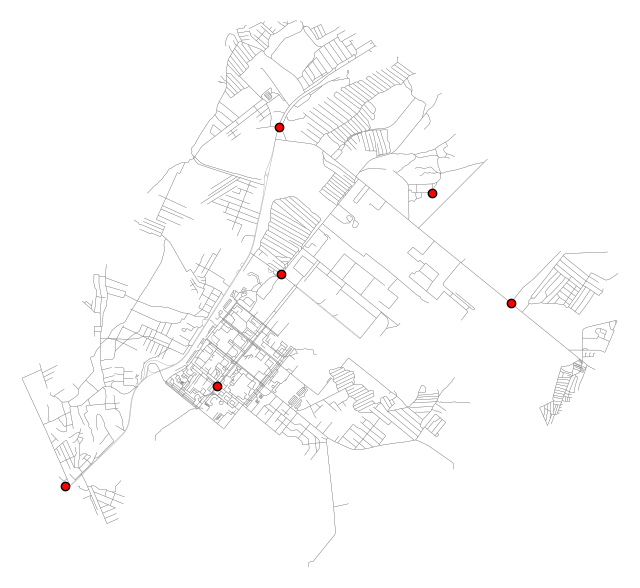

In [11]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[units].plot(ax=ax, color='red', edgecolor='black')


# 2. Сопоставление со временем расчета для инструментов **genesis**

Проверка для полученных жадным добавлением размещений

In [12]:
time_bound = 10

In [13]:
units[:5]

[9085465268, 290700365, 886086164, 5574211404, 2034401657]

In [22]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding, CoverIndexBuilding


dynamic_nodes = {}
i = 0
for n in units[:2]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1



# dynamic_nodes = {
#     1998227427: 'pre1',
#     1533814277: 'pre2',
#     1676510285: 'pre3',
#     5940099708: 'pre4',
#     3981463630: 'pre5',
# }

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))

# print_metrics(G, dynamic_nodes, {})

Новых ПСЧ: 2 Всего ПСЧ: 6
ИП-10 =  95.39078156312625 %, tпр =  7.216026703893198 6.400452470985316


In [21]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState


def iter_func(**kwds):
    'Функция вывода хода расчета'
    i = kwds['i']
    best_metric = kwds['best_metric']
    print(f'Копт: шаг {i} лучшая метирка: {best_metric}')

# mclp_history = []
def mclp_end_function(iteration, best_metric, dynamic_nodes, static_nodes, **kwargs):
    units_count = len(dynamic_nodes) + len(static_nodes)
    msg = f'Итерация: {iteration} | Подразделений {units_count} | Лучшая метрика: {best_metric}'
    print(msg)


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

def print_metrics(env, dynamic_nodes, existed_units_dict, ip_val=3):
    all_nodes = {**existed_units_dict, **dynamic_nodes}
    times, _ = FirstArrivalUnitState()(env = env, points = all_nodes)
    print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(all_nodes))
    print(f'ИП-{ip_val} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times))

In [19]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.metrics import ArrivalTimeBuilding
from fire_units.mclp import BestNodesGAKopt
from genesis.best_points import BestNodeBee
from genesis.mclp import BestNodesKoptG
from genesis.point_selectors import RandomNodesSelector
from genesis.stop_cases import NSameStopCase


# metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)
metric_target = ArrivalTimeBuilding(buildings)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
abc = BestNodeBee(state_function=FirstArrivalUnitState(),
                  metric_function=ArrivalTime(),
                  scouts_count=20,
                  best_scouts_count=4)


kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=abc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


mclp = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 200,
                    epochs = 25,
                    elite_size = 25,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 10,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )



best_dynamic_nodes, best_metric = mclp(env = G,
                                dynamic_nodes = dynamic_nodes,
                                )

times, _ = FirstArrivalUnitState()(env = G, points = best_dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), metric_target(times))

Эпоха: 0 | Лучшая метрика: 6.274963104895334 | Текущая метрика: 6.274963104895334 |
Эпоха: 1 | Лучшая метрика: 6.0217360640828375 | Текущая метрика: 6.0217360640828375 |
Эпоха: 2 | Лучшая метрика: 6.0217360640828375 | Текущая метрика: 6.0217360640828375 |
Эпоха: 3 | Лучшая метрика: 6.0217360640828375 | Текущая метрика: 6.0217360640828375 |
Эпоха: 4 | Лучшая метрика: 6.01995046095238 | Текущая метрика: 6.01995046095238 |
Эпоха: 5 | Лучшая метрика: 6.01995046095238 | Текущая метрика: 6.01995046095238 |
Эпоха: 6 | Лучшая метрика: 6.01995046095238 | Текущая метрика: 6.01995046095238 |
Эпоха: 7 | Лучшая метрика: 6.01995046095238 | Текущая метрика: 6.01995046095238 |
Эпоха: 8 | Лучшая метрика: 5.861769623476321 | Текущая метрика: 5.861769623476321 |
Эпоха: 9 | Лучшая метрика: 5.861769623476321 | Текущая метрика: 5.861769623476321 |
Эпоха: 10 | Лучшая метрика: 5.861769623476321 | Текущая метрика: 5.861769623476321 |
Эпоха: 11 | Лучшая метрика: 5.861769623476321 | Текущая метрика: 5.8617696234

In [20]:
times, _ = FirstArrivalUnitState()(env = G, points = best_dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), metric_target(times))

Новых ПСЧ: 2 Всего ПСЧ: 6
ИП-10 =  83.0995323981296 %, tпр =  9.04483524220444 5.861769623476321


In [ ]:

from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase


target_ip = 99


# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings, ip_val = 10)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


mclp = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 75,
                    epochs = 25,
                    elite_size = 20,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 5,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = mclp,
                    # mclp_function = kopt,
                    point_selector = RandomNodesSelector(),
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=10),     # stop_case_function,
                    start_names_index = 10,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[100]: 'псч А',
    list(nodes_gdf.index)[200]: 'псч Б',
    # list(nodes_gdf.index)[300]: 'псч В',
}

t()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())
# mclp_end_function('add', best_metric, optimal_nodes)

Оптимизация размещения N подразделений аналогичных предложенным при помощи жадного добавления

In [ ]:
# import random

# # Создание словаря предварительно размещенных подразделений
# dynamic_nodes = {}
# i = 1
# # for n in random.choices(list(nodes_gdf.index), k=9):
# for n in units[:9]:
#     dynamic_nodes[n] = f'pre {i}'
#     i += 1

# dynamic_nodes

{1998227427: 'pre 1',
 1533814277: 'pre 2',
 1676510285: 'pre 3',
 5940099708: 'pre 4',
 3981463630: 'pre 5',
 290700344: 'pre 6',
 1533814276: 'pre 7',
 868999655: 'pre 8',
 1998227475: 'pre 9'}

In [22]:
from genesis.best_points import BestNodeBee


metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
abc = BestNodeBee(state_function=FirstArrivalUnitState(),
                  metric_function=ArrivalTime(),
                  scouts_count=20,
                  best_scouts_count=4)


kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(,
                       metric_function = metric_target,
                       best_point_function=abc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


mclp = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 200,
                    epochs = 25,
                    elite_size = 25,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 10,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )



# best_dynamic_nodes, best_metric = mclp(env = G,
#                                 dynamic_nodes = optimal_nodes,
#                                 )

In [23]:
best_dynamic_nodes, best_metric = kopt(env = G,
                                dynamic_nodes = optimal_nodes,
                                )

Копт: шаг 0 лучшая метирка: 90.91516366065464
Копт: шаг 1 лучшая метирка: 90.91516366065464
Копт: шаг 2 лучшая метирка: 90.91516366065464


In [24]:
best_metric

90.91516366065464